# OSM roads with real noise values (dB) — Berlin

Regression counterpart of `BER_OSM_roads_noise_class.ipynb`, mirroring Barcelona's `OSM_roads_noise_regre.ipynb`.

The raw dB values were already computed by the class pipeline (same segments, same noise assignment) and stored in `../layers/BER_noise_streets.gpkg`; here they simply replace the 0–4 noise classes, so all road features stay **identical** to the classification dataset.

Berlin only publishes Lden (day-evening-night composite) and Lnight — day and evening dB are both the per-segment Lden mean, night is the Lnight mean, as in the class pipeline.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt

## Load the class-pipeline road features and the noise streets layer

In [2]:
roads_class = pd.read_csv("data/osm_roads_noise_class.csv")
noise_streets = gpd.read_file("../layers/BER_noise_streets.gpkg")

print("Class CSV:", roads_class.shape)
print("Noise streets:", noise_streets.shape)
roads_class.head()

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Class CSV: (70890, 12)
Noise streets: (70890, 12)


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,dist_to_main
0,172539_172562_0,2,2,1,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539,0.0
1,172539_34694336_0,2,2,1,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362,0.0
2,172539_34694265_0,2,2,1,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362,0.0
3,172545_271370539_0,3,3,2,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367,0.0
4,172545_34694336_0,2,2,1,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367,0.0


## Replace the noise classes with the raw dB values

In [3]:
db = noise_streets[['segment_id']].copy()
db['noise_day'] = noise_streets['GES_DEN_mean'].astype(float)
db['noise_evening'] = noise_streets['GES_DEN_mean'].astype(float)
db['noise_night'] = noise_streets['GES_N_mean'].astype(float)
db['segment_id'] = db['segment_id'].astype(str)

roads_regre = roads_class.drop(columns=['noise_day', 'noise_evening', 'noise_night']).copy()
roads_regre['road_id'] = roads_regre['road_id'].astype(str)
roads_regre = roads_regre.merge(db, left_on='road_id', right_on='segment_id', how='left')
roads_regre = roads_regre.drop(columns=['segment_id'])

# restore the Barcelona column order: noise columns right after road_id
noise_cols = ['noise_day', 'noise_evening', 'noise_night']
ordered = ['road_id'] + noise_cols + [c for c in roads_regre.columns if c != 'road_id' and c not in noise_cols]
roads_regre = roads_regre[ordered]

print(f"Rows: {len(roads_regre)} (class CSV: {len(roads_class)})")
roads_regre[noise_cols].describe()

Rows: 70890 (class CSV: 70890)


,noise_day,noise_evening,noise_night
count,70890.000000,70890.000000,70890.000000
mean,52.216621,52.216621,44.551293
std,8.584459,8.584459,8.416265
min,24.790909,24.790909,16.772727
25%,45.600000,45.600000,38.146488
50%,50.475000,50.475000,42.900002
75%,58.034805,58.034805,50.120000
max,89.099998,89.099998,81.900002


## Sanity checks

In [4]:
assert len(roads_regre) == len(roads_class), "row count changed by the merge"
assert roads_regre[noise_cols].isna().sum().sum() == 0, "NaN noise values after merge"
print("dB ranges:")
print(roads_regre[noise_cols].agg(['min', 'max']))
print("All sanity checks passed.")

dB ranges:
     noise_day  noise_evening  noise_night
min  24.790909      24.790909    16.772727
max  89.099998      89.099998    81.900002
All sanity checks passed.


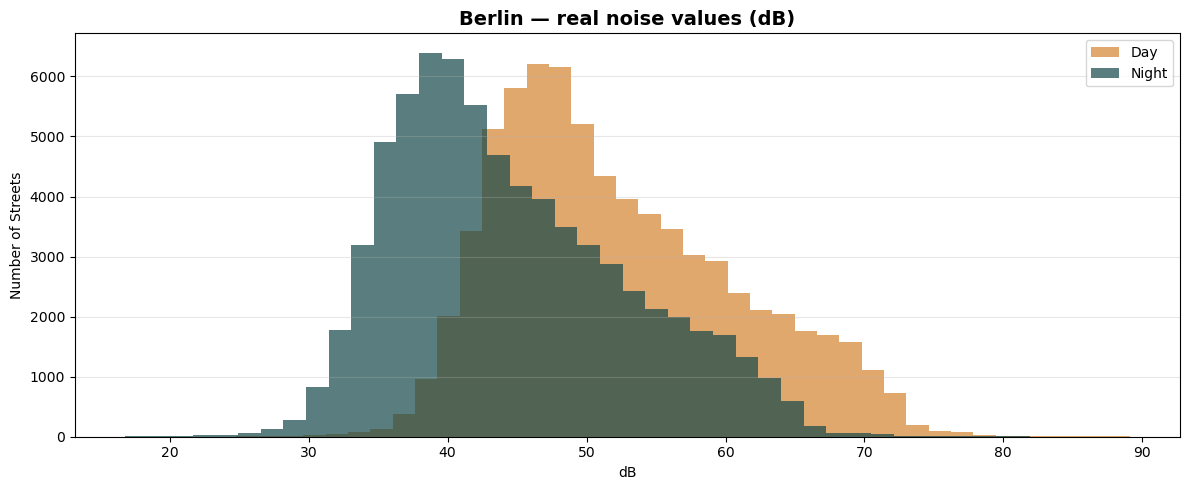

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roads_regre['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(roads_regre['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Berlin — real noise values (dB)', fontsize=14, fontweight='bold')
ax.set_xlabel('dB')
ax.set_ylabel('Number of Streets')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Export to CSV

In [6]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
roads_regre.to_csv(os.path.join(output_dir, "osm_roads_noise_regre.csv"), index=False)
print("Exported osm_roads_noise_regre.csv")

Exported osm_roads_noise_regre.csv
